In [1]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
import pandas as pd
import numpy as np
import sys
from copy import deepcopy,copy
from datetime import datetime
import pickle
import sys
import matplotlib.pyplot as plt
import warnings
from scipy.signal import savgol_filter
#warnings.filterwarnings("ignore")
#warnings.filterwarnings("ignore", category=RuntimeWarning)
stderr_fileno = sys.stderr
sys.stderr = open(os.devnull, 'w')

src = os.path.dirname('/export/home/oriolca/Integral_BMS_Governing_Equations/I-BMS/')
sys.path.append(src)
from mcmc_ode import *
from parallel_ode import *

path = os.path.join(src, "Prior/")
sys.path.append(path)
from fit_prior import read_prior_par

priors = {
    "v2_p3": f"Prior/final_prior_param_sq.named_equations.nv2.np3.2016-09-09 18:49:42.927679.dat",
    "v2_p4": f"Prior/final_prior_param_sq.named_equations.nv2.np4.2016-09-09 18:49:43.056910.dat",
    "v2_p8": f"Prior/final_prior_param_sq.named_equations.nv2.np8.2016-09-09 18:49:42.800618.dat",
}

#data=pd.read_csv('../Lotka-Volterra/noise_data/1.0_0.csv')
data=pd.read_csv('../Lotka-Volterra/noise_data/1000_0.csv')

print(data)

x = data[['x','y']]
t = pd.Series(data[['t']].t)

dt = t.to_numpy()[1] - t.to_numpy()[0]
window_length = 41    # must be odd and <= len(t)
polyorder = 3         # generally 2..5

x_hat = savgol_filter(x['x'], window_length, polyorder, delta=dt, mode='interp')
y_hat = savgol_filter(x['y'], window_length, polyorder, delta=dt, mode='interp')

#x['x'] = x_hat
#x['y'] = y_hat

x_dot = savgol_filter(x['x'], window_length, polyorder, deriv=1, delta=dt, mode='interp')
y_dot = savgol_filter(x['y'], window_length, polyorder, deriv=1, delta=dt, mode='interp')

dx = [pd.DataFrame(data = {'x': x_hat, 'y': y_hat}),pd.DataFrame(data = {'x': x_dot, 'y': y_dot})]

print(x)

print(t)

print(dx)

     Unnamed: 0          x          y      t        dx        dy
0             0   6.985615   9.417849    0.0 -0.000652 -5.183112
1             1   9.687888  10.691576    0.5 -0.065845 -3.910672
2             2  18.589692   4.149509    1.0 -0.037104 -2.802677
3             3   8.356284   4.956917    1.5  0.047917 -1.847633
4             4   5.063140   3.413960    2.0  0.164472 -1.037486
..          ...        ...        ...    ...       ...       ...
995         995  23.841054   6.859406  497.5 -3.496829  1.857438
996         996  24.334096  14.699745  498.0 -3.796006  2.439883
997         997  14.364860  15.543812  498.5 -4.074484  3.143675
998         998  19.389339  16.334902  499.0 -4.328595  3.923919
999         999  15.816036  15.968117  499.5 -4.555566  4.727894

[1000 rows x 6 columns]
             x          y
0     6.985615   9.417849
1     9.687888  10.691576
2    18.589692   4.149509
3     8.356284   4.956917
4     5.063140   3.413960
..         ...        ...
995  23.84105

In [2]:
%%time
XLABS = ['x','y']
n_params = 8

path = os.path.join(src, priors[f"v{len(XLABS)}_p{str(n_params)}"])
prior_par = read_prior_par(path)

Ts=[1] + [1.04**k for k in range(1, 20)]

del prior_par['Nopi_abs']
del prior_par['Nopi2_abs']
del prior_par['Nopi_tan']
del prior_par['Nopi2_tan']
del prior_par['Nopi_sinh']
del prior_par['Nopi2_sinh']
del prior_par['Nopi_cosh']
del prior_par['Nopi2_cosh']
del prior_par['Nopi_tanh']
del prior_par['Nopi2_tanh']


OPS = {
    "sin": 1,
    "cos": 1,
    "exp": 1,
    "pow2": 1,
    "pow3": 1,
    "-": 1,
    "+": 2,
    "*": 2,
    "/": 2,
    "**": 2,
}
import time

start = time.time()
model_x = Tree(
    ops=OPS,
    variables=XLABS,
    parameters=["a%d" % i for i in range(n_params)],
    x=x, t=t, dx=dx,
    prior_par=prior_par,
    from_string = '((_a0_ * x) + (_a1_ * (y * x)))'
)

print(model_x)
print(model_x.E)

model_y = Tree(
    ops=OPS,
    variables=XLABS,
    parameters=["a%d" % i for i in range(n_params)],
    x=x, t=t, dx=dx,
    prior_par=prior_par,
    from_string ='((_a2_ * y) + (_a3_ * (y * x)))'
)
print(model_y)
print(model_y.E)
print('Set couplings')

#model_x.par_values['d0'] = {'_a0_': 0.1, '_a1_': -0.02, '_a2_': -0.4, '_a3_': 0.02, '_a4_': 1.0, '_a5_': 1.0, '_a6_': 1.0, '_a7_': 1.0}
#model_x.x0_values['d0'] = np.array([10. , 5.])

couplings=[model_x,model_y]
model_x.set_couplings(couplings)

print(model_x)
print(model_x.E.val)
print(model_x.par_values.copy())
print(model_x.x0_values.copy())

((_a0_ * x) + (_a1_ * (y * x)))
<SharedNumber inf>
((_a2_ * y) + (_a3_ * (y * x)))
<SharedNumber inf>
Set couplings
((_a0_ * x) + (_a1_ * (y * x)))
2998.10867106294
{'d0': {'_a0_': 0.16804845308472574, '_a1_': -0.028001625636165286, '_a2_': -0.22197579292848568, '_a3_': 0.011126433408700868, '_a4_': 1.0, '_a5_': 1.0, '_a6_': 1.0, '_a7_': 1.0}}
{'d0': array([10.36679101,  7.15948903])}
CPU times: user 9.66 s, sys: 40.8 ms, total: 9.7 s
Wall time: 9.71 s


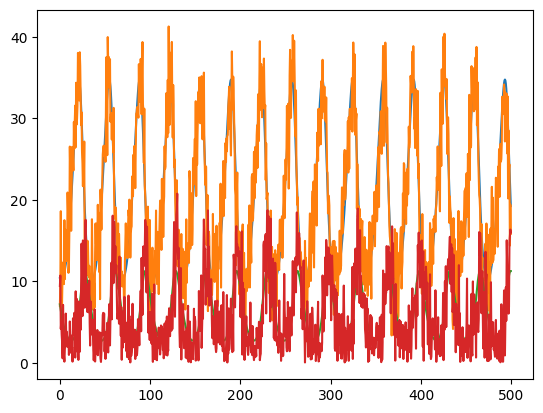

<SharedDict {'((_a0_ * x) + (_a1_ * (y * x)))': ({'d0': inf}, None), ('((_a0_ * x) + (_a1_ * (y * x)))', '((_a2_ * y) + (_a3_ * (y * x)))'): ({'d0': 20875.5597278811}, None)}>


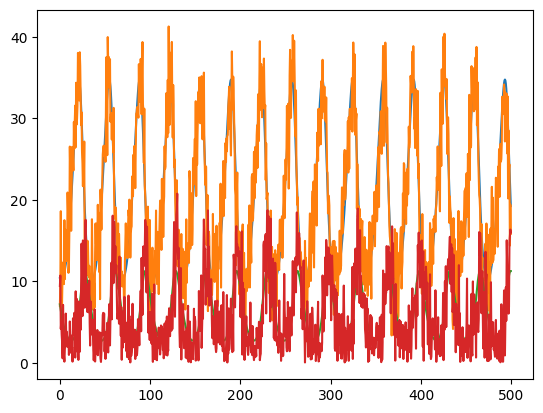

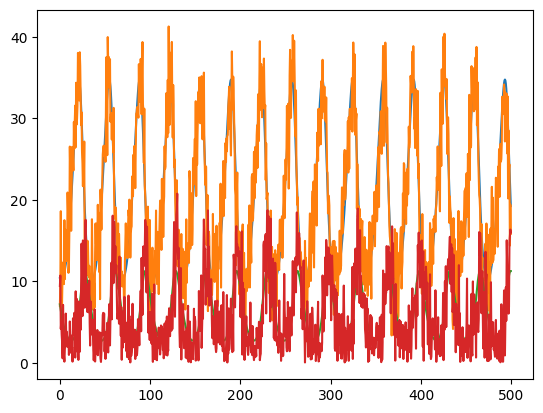

In [3]:
integral = model_x.integrate(t)

plt.plot(t,integral['d0']['x'])
plt.plot(t,x['x'])
plt.plot(t,integral['d0']['y'])
plt.plot(t,x['y'])
plt.show()

print(model_x.fit_sse)
del model_x.fit_sse[(str(model_x),str(model_y))]
model_x.get_sse(fit=True)
integral = model_x.integrate(t)

plt.plot(t,integral['d0']['x'])
plt.plot(t,x['x'])
plt.plot(t,integral['d0']['y'])
plt.plot(t,x['y'])
plt.show()

# True parameters

integral = model_x.integrate(t)

plt.plot(t,integral['d0']['x'])
plt.plot(t,x['x'])
plt.plot(t,integral['d0']['y'])
plt.plot(t,x['y'])
plt.show()



# Comparing SSE from BMS:
print(model_x.sse,model_y.sse)
model_y.get_sse(fit=True)
print(model_x.sse,model_y.sse)
# and actual sse:
data1=pd.read_csv('../Lotka-Volterra/noise_data/0.1_0.csv')
print(np.sum((-integral['d0'].to_numpy() + x.to_numpy())**2.))

plt.plot(t,data1['x'])
plt.plot(t,x['x'])
plt.plot(t,data1['y'])
plt.plot(t,x['y'])
plt.show()

# True parameters
model_x.integrator=Integrator('rk4')
model_x.par_values['d0'] = {'_a0_': 0.1, '_a1_': -0.02, '_a2_': -0.4, '_a3_': 0.02, '_a4_': 1.0, '_a5_': 1.0, '_a6_': 1.0, '_a7_': 1.0}
model_x.x0_values['d0'] = np.array([10. , 5.])
integral = model_x.integrate(t)

plt.plot(t,integral['d0']['x'])
plt.plot(t,x['x'])
plt.plot(t,integral['d0']['y'])
plt.plot(t,x['y'])
plt.show()

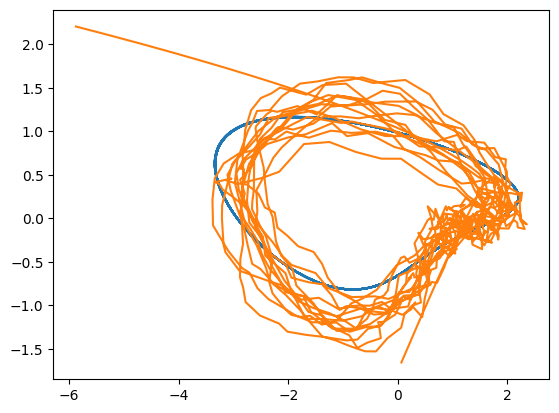

In [4]:
dx_pred = model_x.predict(integral['d0'])

n=min(len(dx_pred),200000)
plt.plot(dx_pred['x'][:n],dx_pred['y'][:n])
plt.plot(dx[1]['x'][:n],dx[1]['y'][:n],)